In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200
...,...,...,...,...,...
2023-12-22,191.609451,193.400839,190.985924,193.173193,37149600
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300


In [3]:
df.head()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


In [5]:
df['Next_Close'] = df['Close'].shift(-1)

In [6]:
df

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400,71.696625
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,72.267944
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,71.928040
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000,73.085121
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,74.637497
...,...,...,...,...,...,...
2023-12-22,191.609451,193.400839,190.985924,193.173193,37149600,191.065125
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300,191.164108


In [7]:
df = df.dropna()

In [8]:
df

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400,71.696625
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,72.267944
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,71.928040
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000,73.085121
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,74.637497
...,...,...,...,...,...,...
2023-12-21,192.678329,195.053662,191.510469,194.083743,46482500,191.609451
2023-12-22,191.609451,193.400839,190.985924,193.173193,37149600,191.065125


In [14]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

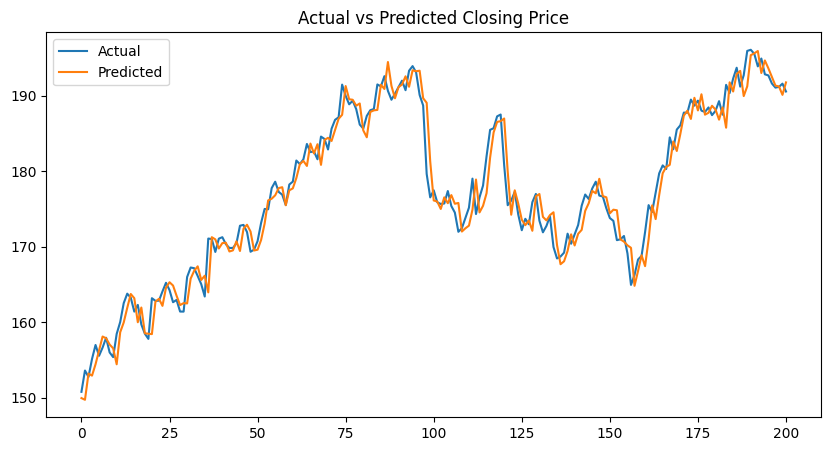

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.show()